# **This LeNet-5 Pruning project was developed and coded by Matin Firoozbakht.**

***Project Summary:***

This project explores the impact of network pruning on a LeNet-5 convolutional neural network trained on the Fashion MNIST dataset. The primary objectives were to implement, apply, and evaluate two common magnitude-based pruning techniques:

*   Weight Pruning
*   Neuron/Filter Pruning.

In [14]:
import tensorflow as tf
import tempfile
import zipfile
import os
import h5py
import numpy as np
import glob
from numpy import linalg as LA
from scipy.stats import rankdata
from shutil import copyfile, move
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import keras
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten , InputLayer
from keras.layers import Conv2D, MaxPooling2D

import datetime
import numpy as np
import pandas as pd

In [15]:
# hyperparameters
batch_size = 128
num_classes = 10
initial_training_epochs = 20
fine_tuning_epochs = 5

# Input dimensions
img_rows, img_cols = 28, 28

#Fashion MNIST dataset
(x_train_raw, y_train_int_labels), (x_test_raw, y_test_int_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Preprocess Image Data (x_train, x_test)
if tf.keras.backend.image_data_format() == 'channels_first':
    x_train = x_train_raw.reshape(x_train_raw.shape[0], 1, img_rows, img_cols)
    x_test = x_test_raw.reshape(x_test_raw.shape[0], 1, img_rows, img_cols)
    cnn_input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train_raw.reshape(x_train_raw.shape[0], img_rows, img_cols, 1)
    x_test = x_test_raw.reshape(x_test_raw.shape[0], img_rows, img_cols, 1)
    cnn_input_shape = (img_rows, img_cols, 1)

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print('--- Image Data Shapes ---')
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')
print('Input shape for CNN (cnn_input_shape):', cnn_input_shape)

# Preprocess Label Data (y_train_categorical, y_test_categorical)
y_train_categorical = tf.keras.utils.to_categorical(y_train_int_labels, num_classes)
y_test_categorical = tf.keras.utils.to_categorical(y_test_int_labels, num_classes)

print('\n--- Label Data Shapes (After Fix) ---')
print('Original y_train_int_labels shape:', y_train_int_labels.shape)
print('y_train_categorical shape (one-hot):', y_train_categorical.shape)
print('Original y_test_int_labels shape:', y_test_int_labels.shape)
print('y_test_categorical shape (one-hot):', y_test_categorical.shape)

--- Image Data Shapes ---
x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples
Input shape for CNN (cnn_input_shape): (28, 28, 1)

--- Label Data Shapes (After Fix) ---
Original y_train_int_labels shape: (60000,)
y_train_categorical shape (one-hot): (60000, 10)
Original y_test_int_labels shape: (10000,)
y_test_categorical shape (one-hot): (10000, 10)


In [16]:
model = tf.keras.models.Sequential(name="LeNet5_Model")

model.add(tf.keras.layers.Conv2D(
    filters=6,
    kernel_size=(5, 5),
    activation='relu',
    input_shape=cnn_input_shape,
    padding='same'
))


model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2))

model.add(tf.keras.layers.Conv2D(
    filters=16,
    kernel_size=(5, 5),
    activation='relu',
    padding='valid' # 'valid' padding means no padding (default)
))

model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(120, activation='relu'))
model.add(tf.keras.layers.Dense(84, activation='relu'))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [17]:
model.summary()

Model: "LeNet5_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)


 Starting Initial Model Training for 20 epochs ... 
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.7682 - loss: 0.6272 - val_accuracy: 0.8329 - val_loss: 0.4626
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 72ms/step - accuracy: 0.8501 - loss: 0.4216 - val_accuracy: 0.8534 - val_loss: 0.4048
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.8691 - loss: 0.3592 - val_accuracy: 0.8696 - val_loss: 0.3629
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.8832 - loss: 0.3234 - val_accuracy: 0.8655 - val_loss: 0.3604
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.8899 - loss: 0.2985 - val_accuracy: 0.8798 - val_loss: 0.3293
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 75ms/step - accuracy: 0.8980 - loss: 0.2765 - val_accuracy: 0.8911 - val_loss: 0.3050
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.9046 - loss: 0.2637 - val_accuracy: 0.8891 - val_loss: 0.3068
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━

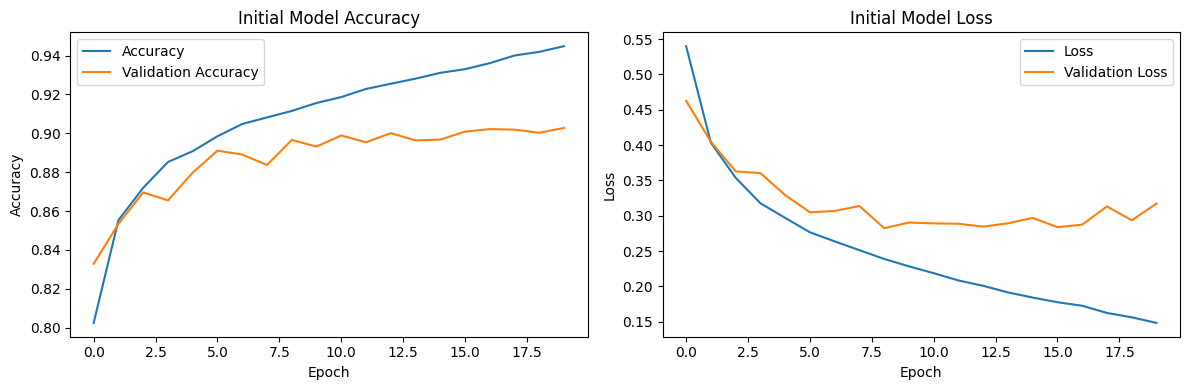

In [19]:
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir_initial = os.path.join("logs", "initial_training", current_time)

tensorboard_callback_initial = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir_initial,
    histogram_freq=1,
    profile_batch=0
)
callbacks_initial = [tensorboard_callback_initial]

model.compile(
    loss=tf.keras.losses.categorical_crossentropy,
    optimizer='adam',
    metrics=['accuracy']
)

print(f"\n Starting Initial Model Training for {initial_training_epochs} epochs ... ")
history = model.fit(
    x_train,
    y_train_categorical,
    batch_size=batch_size,
    epochs=initial_training_epochs,
    callbacks=callbacks_initial,
    validation_data=(x_test, y_test_categorical)
)

print("\n--- Initial Model Evaluation ---")
score = model.evaluate(
    x_test,
    y_test_categorical,
    verbose=0
)
print(f'Test loss: {score[0]:.4f}')
print(f'Test accuracy: {score[1]:.4f}')

# Optional: Plot training history
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Initial Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Initial Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# specific directory for saved models
saved_models_dir = "saved_models"
os.makedirs(saved_models_dir, exist_ok=True)

# full path for the model file
model_file_path = os.path.join(saved_models_dir, "lenet5_unpruned_fashionmnist.keras")

print(f"\n Saving the initial unpruned model to: {model_file_path} ")
tf.keras.models.save_model(
    model,
    model_file_path,
    include_optimizer=False
)


 Saving the initial unpruned model to: saved_models/lenet5_unpruned_fashionmnist.keras 


# Weight pruning

In [7]:
print("\n Starting Weight Pruning ... ")

# Load the original, unpruned model
print(f"Loading original model from: {model_file_path}")
orig_model = tf.keras.models.load_model(model_file_path)

# Define a directory for saving weight-pruned models
pruned_wp_models_dir = os.path.join("saved_models", "pruned_weight")
os.makedirs(pruned_wp_models_dir, exist_ok=True)

pruning_ratios = [0.25, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.97, 0.99]

for sparsity_ratio in pruning_ratios:
    print(f"\n--- Weight Pruning with Sparsity Ratio: {sparsity_ratio:.2f} ---")
    # Clone the original model for each pruning iteration
    pruned_model_wp = tf.keras.models.clone_model(orig_model)
    pruned_model_wp.set_weights(orig_model.get_weights())

    for layer_index, layer in enumerate(pruned_model_wp.layers):
        original_layer_weights = layer.get_weights()

        # Check if the layer has weights and if the kernel is a matrix/tensor (not just a bias vector)
        if original_layer_weights and len(original_layer_weights[0].shape) > 1:
            kernel_weights = original_layer_weights[0] # weights[0] is kernel

            if kernel_weights.size == 0: # Skip if kernel is empty for some reason
                continue

            # Calculate ranks based on absolute magnitude of weights
            abs_weights_flat = np.abs(kernel_weights.flatten())
            ranks_flat = rankdata(abs_weights_flat, method='dense') - 1

            # Determine the rank threshold for pruning
            threshold_rank = np.ceil(np.max(ranks_flat) * sparsity_ratio).astype(int)

            pruning_mask_flat = ranks_flat <= threshold_rank

            # Reshape mask to kernel's shape and invert (True for keep, False for prune)
            # Or, more simply, create a keep_mask directly :)))
            keep_mask_flat = ranks_flat > threshold_rank
            keep_mask = keep_mask_flat.reshape(kernel_weights.shape).astype(float)

            pruned_kernel = kernel_weights * keep_mask

            new_weights_for_layer = [pruned_kernel] + original_layer_weights[1:] # Keep biases
            layer.set_weights(new_weights_for_layer)



    # Fine-tuning Step
    print(f"Fine-tuning weight-pruned model (sparsity: {sparsity_ratio:.2f})...")
    # Use a smaller learning rate for fine-tuning
    fine_tune_optimizer_wp = tf.keras.optimizers.Adam(learning_rate=1e-4)
    pruned_model_wp.compile(
        loss=tf.keras.losses.categorical_crossentropy,
        optimizer=fine_tune_optimizer_wp,
        metrics=['accuracy']
    )

    pruned_model_wp.fit(
        x_train,
        y_train_categorical,
        batch_size=batch_size,
        epochs=fine_tuning_epochs,
        verbose=1, # Or 0 for silent, 1 for progress bar
        validation_data=(x_test, y_test_categorical)
    )
    # End of Fine-tuning Step

    # Save the pruned and fine-tuned model
    save_path = os.path.join(pruned_wp_models_dir, f"wp_model_sparsity_{sparsity_ratio:.2f}.keras")
    pruned_model_wp.save(save_path, include_optimizer=False)
    print(f"Saved weight-pruned and fine-tuned model to: {save_path}")


 Starting Weight Pruning ... 
Loading original model from: saved_models/lenet5_unpruned_fashionmnist.keras

--- Weight Pruning with Sparsity Ratio: 0.25 ---
Fine-tuning weight-pruned model (sparsity: 0.25)...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.9526 - loss: 0.1288 - val_accuracy: 0.9094 - val_loss: 0.2785
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.9592 - loss: 0.1161 - val_accuracy: 0.9099 - val_loss: 0.2784
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.9601 - loss: 0.1141 - val_accuracy: 0.9104 - val_loss: 0.2831
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.9601 - loss: 0.1103 - val_accuracy: 0.9109 - val_loss: 0.2836
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 69ms/step - accuracy: 0.9614 - loss: 0.1086 - val_accuracy: 0.9085 - val_loss: 0.2886
Saved weight-pruned and fine-tuned model to: saved_models/pruned_weight/wp_model_sparsity_0.25.keras

--- Weight Pruning with Sparsity Ratio: 0.5

# Neuron pruning

In [24]:
print("\n Starting Neuron/Filter Pruning (with fix for filter_norms)... ")

# Load the original, unpruned model
print(f"Loading original model from: {model_file_path}")
orig_model_for_nf_pruning = tf.keras.models.load_model(model_file_path)

# Define a directory for saving neuron/filter-pruned models
pruned_nf_models_dir = os.path.join("saved_models", "pruned_neuron_filter")
os.makedirs(pruned_nf_models_dir, exist_ok=True)

pruning_ratios = [0.25, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.97, 0.99]

for sparsity_ratio in pruning_ratios:
    print(f"\n--- Neuron/Filter Pruning with Sparsity Ratio: {sparsity_ratio:.2f} ---")
    pruned_model_nf = tf.keras.models.clone_model(orig_model_for_nf_pruning)
    pruned_model_nf.set_weights(orig_model_for_nf_pruning.get_weights())

    for layer_index, layer in enumerate(pruned_model_nf.layers):
        original_layer_weights = layer.get_weights()

        if not original_layer_weights:
            continue

        kernel_weights = original_layer_weights[0]

        if isinstance(layer, tf.keras.layers.Dense) and len(kernel_weights.shape) == 2:
            print(f"Pruning Dense layer: {layer.name} (Shape: {kernel_weights.shape})")
            neuron_norms = np.linalg.norm(kernel_weights, axis=0)

            if neuron_norms.size == 0:
                continue

            ranks_of_norms = rankdata(neuron_norms, method='dense') - 1
            threshold_rank_neuron = np.ceil(np.max(ranks_of_norms) * sparsity_ratio).astype(int)
            keep_mask_neuron = (ranks_of_norms > threshold_rank_neuron).astype(float)
            pruned_kernel = kernel_weights * keep_mask_neuron
            new_weights_for_layer = [pruned_kernel] + original_layer_weights[1:]
            layer.set_weights(new_weights_for_layer)

        elif isinstance(layer, tf.keras.layers.Conv2D) and len(kernel_weights.shape) == 4:
            print(f"Pruning Conv2D layer (Filter Pruning): {layer.name}")
            print(f"    DEBUG: Shape of kernel_weights for Conv2D layer {layer.name}: {kernel_weights.shape}")

            # MODIFIED CALCULATION FOR filter_norms
            num_filters = kernel_weights.shape[-1]
            reshaped_kernels = kernel_weights.reshape(-1, num_filters)
            # Calculate L2 norm along axis 0
            filter_norms = np.linalg.norm(reshaped_kernels, axis=0)
            # --- END OF MODIFIED CALCULATION ---

            if filter_norms.size == 0:
                print(f"    Skipping Conv2D layer {layer.name} (empty filter norms).")
                continue

            print(f"    DEBUG: Shape of filter_norms for {layer.name}: {filter_norms.shape}")

            ranks_of_filter_norms = rankdata(filter_norms, method='dense') - 1
            threshold_rank_filter = np.ceil(np.max(ranks_of_filter_norms) * sparsity_ratio).astype(int)
            keep_mask_filter = (ranks_of_filter_norms > threshold_rank_filter).astype(float)
            keep_mask_filter_reshaped = keep_mask_filter.reshape(1, 1, 1, -1)
            pruned_kernel = kernel_weights * keep_mask_filter_reshaped
            new_weights_for_layer = [pruned_kernel] + original_layer_weights[1:]
            layer.set_weights(new_weights_for_layer)

    # --- Fine-tuning Step ---
    print(f"Fine-tuning neuron/filter-pruned model (sparsity: {sparsity_ratio:.2f})...")
    fine_tune_optimizer_nf = tf.keras.optimizers.Adam(learning_rate=1e-4)
    pruned_model_nf.compile(
        loss=tf.keras.losses.categorical_crossentropy,
        optimizer=fine_tune_optimizer_nf,
        metrics=['accuracy']
    )
    pruned_model_nf.fit(
        x_train,
        y_train_categorical,
        batch_size=batch_size,
        epochs=fine_tuning_epochs,
        verbose=1,
        validation_data=(x_test, y_test_categorical)
    )
    # --- End of Fine-tuning Step ---

    save_path = os.path.join(pruned_nf_models_dir, f"nf_model_sparsity_{sparsity_ratio:.2f}.keras")
    pruned_model_nf.save(save_path, include_optimizer=False)
    print(f"Saved neuron/filter-pruned and fine-tuned model to: {save_path}")


 Starting Neuron/Filter Pruning (with fix for filter_norms)... 
Loading original model from: saved_models/lenet5_unpruned_fashionmnist.keras

--- Neuron/Filter Pruning with Sparsity Ratio: 0.25 ---
Pruning Conv2D layer (Filter Pruning): conv2d_4
    DEBUG: Shape of kernel_weights for Conv2D layer conv2d_4: (5, 5, 1, 6)
    DEBUG: Shape of filter_norms for conv2d_4: (6,)
Pruning Conv2D layer (Filter Pruning): conv2d_5
    DEBUG: Shape of kernel_weights for Conv2D layer conv2d_5: (5, 5, 6, 16)
    DEBUG: Shape of filter_norms for conv2d_5: (16,)
Pruning Dense layer: dense_6 (Shape: (400, 120))
Pruning Dense layer: dense_7 (Shape: (120, 84))
Pruning Dense layer: dense_8 (Shape: (84, 10))
Fine-tuning neuron/filter-pruned model (sparsity: 0.25)...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 70ms/step - accuracy: 0.6878 - loss: 1.0039 - val_accuracy: 0.8332 - val_loss: 0.5180
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 72ms/step - accuracy: 0.8516 - loss: 0.4277 - val_accuracy: 0.8579 - val_l

In [25]:
print("\n Evaluating My Pruned Models ...")

# Paths to the directories where pruned models were saved
pruned_wp_models_dir = os.path.join("saved_models", "pruned_weight")
pruned_nf_models_dir = os.path.join("saved_models", "pruned_neuron_filter")

# Collect pruned model file paths
files_weights = sorted(glob.glob(os.path.join(pruned_wp_models_dir, 'wp_model_sparsity_*.keras')))
files_neuron_filter = sorted(glob.glob(os.path.join(pruned_nf_models_dir, 'nf_model_sparsity_*.keras')))

# Accuracy storage
accuracy_weights = []
accuracy_neuron_filter = []

# Evaluate weight-pruned models
print("\nEvaluating Weight-Pruned Models:")
if not files_weights:
    print("No weight-pruned models found. Check the path and filename pattern.")
for f_path in files_weights:
    print(f"Loading and evaluating weight-pruned model: {f_path}")
    restored_model_wp = tf.keras.models.load_model(f_path, compile=False)
    restored_model_wp.compile(
        loss=tf.keras.losses.categorical_crossentropy,
        optimizer='adam',
        metrics=['accuracy']
    )
    score = restored_model_wp.evaluate(x_test, y_test_categorical, verbose=0)
    accuracy_weights.append(score[1])
    print(f"  Model ({os.path.basename(f_path)}): Test Accuracy = {score[1]:.4f}, Test Loss = {score[0]:.4f}")

# Evaluate neuron/filter-pruned models
print("\nEvaluating Neuron/Filter-Pruned Models:")
if not files_neuron_filter:
    print("No neuron/filter-pruned models found. Check the path and filename pattern.")
for f_path in files_neuron_filter:
    print(f"Loading and evaluating neuron/filter-pruned model: {f_path}")
    restored_model_nf = tf.keras.models.load_model(f_path, compile=False)
    restored_model_nf.compile(
        loss=tf.keras.losses.categorical_crossentropy,
        optimizer='adam',
        metrics=['accuracy']
    )
    score = restored_model_nf.evaluate(x_test, y_test_categorical, verbose=0)
    accuracy_neuron_filter.append(score[1])
    print(f"  Model ({os.path.basename(f_path)}): Test Accuracy = {score[1]:.4f}, Test Loss = {score[0]:.4f}")


 Evaluating My Pruned Models ...

Evaluating Weight-Pruned Models:
Loading and evaluating weight-pruned model: saved_models/pruned_weight/wp_model_sparsity_0.25.keras
  Model (wp_model_sparsity_0.25.keras): Test Accuracy = 0.9085, Test Loss = 0.2886
Loading and evaluating weight-pruned model: saved_models/pruned_weight/wp_model_sparsity_0.50.keras
  Model (wp_model_sparsity_0.50.keras): Test Accuracy = 0.9109, Test Loss = 0.2733
Loading and evaluating weight-pruned model: saved_models/pruned_weight/wp_model_sparsity_0.60.keras
  Model (wp_model_sparsity_0.60.keras): Test Accuracy = 0.9082, Test Loss = 0.2652
Loading and evaluating weight-pruned model: saved_models/pruned_weight/wp_model_sparsity_0.70.keras
  Model (wp_model_sparsity_0.70.keras): Test Accuracy = 0.9076, Test Loss = 0.2676
Loading and evaluating weight-pruned model: saved_models/pruned_weight/wp_model_sparsity_0.80.keras
  Model (wp_model_sparsity_0.80.keras): Test Accuracy = 0.8942, Test Loss = 0.2941
Loading and evalu

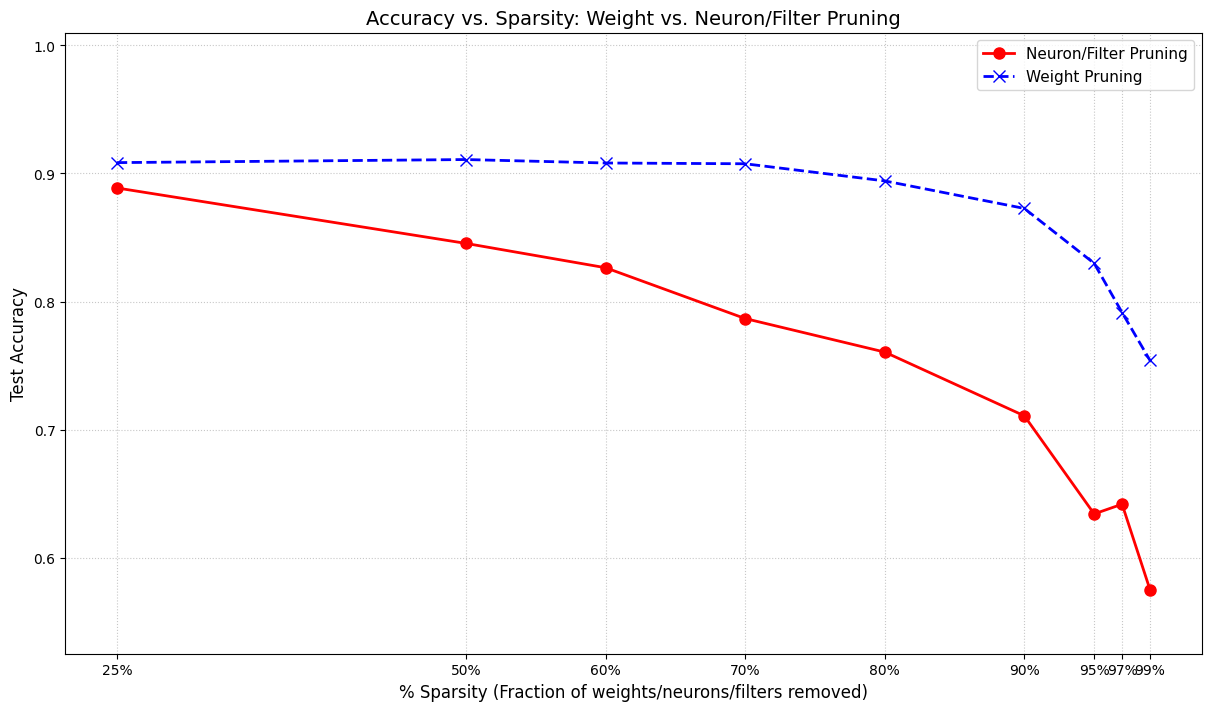

In [28]:
plt.rcParams['figure.constrained_layout.use'] = True

plt.figure(figsize=(12, 7))

# Plotting Neuron/Filter Pruning
plt.plot(pruning_ratios, accuracy_neuron_filter,
         color='red',
         marker='o',
         linestyle='-',
         linewidth=2,
         markersize=8,
         label='Neuron/Filter Pruning')

# Plotting Weight Pruning
plt.plot(pruning_ratios, accuracy_weights,
         color='blue',
         marker='x',
         linestyle='--',
         linewidth=2,
         markersize=8,
         label='Weight Pruning')

plt.xlabel('% Sparsity (Fraction of weights/neurons/filters removed)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Accuracy vs. Sparsity: Weight vs. Neuron/Filter Pruning', fontsize=14)

plt.xticks(ticks=pruning_ratios,
           labels=[f"{r*100:.0f}%" for r in pruning_ratios],
           fontsize=10)
plt.yticks(fontsize=10)


min_accuracy = min(min(accuracy_neuron_filter, default=1.0), min(accuracy_weights, default=1.0))

if not accuracy_neuron_filter and not accuracy_weights:
    min_accuracy_plot = 0.0
else:
    min_accuracy_plot = max(0, min_accuracy - 0.05)

plt.ylim(bottom=min_accuracy_plot, top=1.01)

plt.legend(loc='best', fontsize=11)
plt.grid(True, linestyle=':', linewidth=0.8, alpha=0.7)

plt.show()

In [29]:
results_size_comparison = []

pruned_keras_files_combined = files_neuron_filter + files_weights
pruning_types_combined = ['Neuron/Filter'] * len(files_neuron_filter) + ['Weight'] * len(files_weights)


if len(files_neuron_filter) == len(pruning_ratios) and len(files_weights) == len(pruning_ratios):
    sparsity_levels_combined = pruning_ratios * 2 # If both types have all ratios
else:
    print("Warning: Number of pruned files does not match expected number of pruning ratios. Sparsity levels in table might be incorrect.")
    sparsity_levels_combined = pruning_ratios * 2

# Size of Unpruned Model
try:
    unpruned_size_mb = os.path.getsize(model_file_path) / float(2**20)

    _, temp_zip_unpruned_path = tempfile.mkstemp('.zip')
    with zipfile.ZipFile(temp_zip_unpruned_path, 'w', compression=zipfile.ZIP_DEFLATED) as f:
        f.write(model_file_path) # Zip the actual model file
    unpruned_zip_mb = os.path.getsize(temp_zip_unpruned_path) / float(2**20)
    print(f"Unpruned model size: {unpruned_size_mb:.2f} MB -> {unpruned_zip_mb:.2f} MB (compressed)\n")
    os.remove(temp_zip_unpruned_path) # Clean up temporary zip file

except FileNotFoundError:
    print(f"Error: Original model file not found at {model_file_path}. Skipping unpruned size calculation.")
    unpruned_size_mb = 0
    unpruned_zip_mb = 0


# --- Size of Pruned Models ---
for i, pruned_file_path in enumerate(pruned_keras_files_combined):
    try:
        size_before_pruning_mb = os.path.getsize(pruned_file_path) / float(2**20)

        _, temp_zip_pruned_path = tempfile.mkstemp('.zip')
        with zipfile.ZipFile(temp_zip_pruned_path, 'w', compression=zipfile.ZIP_DEFLATED) as f:
            f.write(pruned_file_path) # Zip the actual pruned model file
        size_after_zipping_mb = os.path.getsize(temp_zip_pruned_path) / float(2**20)
        os.remove(temp_zip_pruned_path) # Clean up temporary zip file

        compression_ratio = round(size_before_pruning_mb / size_after_zipping_mb, 2) if size_after_zipping_mb > 0 else None

        results_size_comparison.append({
            "Pruning Type": pruning_types_combined[i],
            "Sparsity": sparsity_levels_combined[i], # Assumes this list is correctly aligned
            "Size Before Zipping (MB)": round(size_before_pruning_mb, 2),
            "Size After Zipping (MB)": round(size_after_zipping_mb, 2),
            "Compression Ratio (Model/Zip)": compression_ratio
        })
    except FileNotFoundError:
        print(f"Error: Pruned model file not found at {pruned_file_path}. Skipping this file.")
    except IndexError:
        print(f"Error: Mismatch in sparsity_levels_combined for file {pruned_file_path}. Ensure lists are aligned.")


# Create and print DataFrame
if results_size_comparison:
    df_size_comparison = pd.DataFrame(results_size_comparison)
    print(df_size_comparison.to_string(index=False))
else:
    print("No results to display for model size comparison.")

Unpruned model size: 0.75 MB -> 0.66 MB (compressed)

 Pruning Type  Sparsity  Size Before Zipping (MB)  Size After Zipping (MB)  Compression Ratio (Model/Zip)
Neuron/Filter      0.25                      0.75                     0.50                           1.49
Neuron/Filter      0.50                      0.75                     0.39                           1.89
Neuron/Filter      0.60                      0.75                     0.38                           1.99
Neuron/Filter      0.70                      0.75                     0.33                           2.29
Neuron/Filter      0.80                      0.75                     0.30                           2.46
Neuron/Filter      0.90                      0.75                     0.27                           2.74
Neuron/Filter      0.95                      0.75                     0.26                           2.87
Neuron/Filter      0.97                      0.75                     0.26                        